# **Análise Comparativa da Eficácia de Duas Escovas Dentais na Remoção de Placa Bacteriana**

## **Introdução**

Como parte de um estudo comparativo, foram coletadas medidas do índice de placa bacteriana de 26 crianças em idade pré-escolar, antes e depois do uso de duas escovas dentais: uma escova experimental chamada **Hugger e uma escova DentaClean Classic (Modelo Antigo-Convencional)**, ambas da marca DL.

O objetivo da marca é avaliar se a nova escova é eficaz na remoção da placa bacteriana em comparação ao seu modelo anterior.

Os dados foram registrados em formato Excel e incluem seis variáveis:

    - Sujeito: Número inteiro de 1 a 26.
    - Sexo: F para Feminino, M para Masculino.
    - Hugger_Antes_Escovação: Índice de placa bacteriana antes da escovação com a escova Hugger.
    - Hugger_Depois_Escovação: Índice de placa bacteriana depois da escovação com a escova Hugger.
    - Convencional_Antes_Escovação: Índice de placa bacteriana antes da escovação com a escova convencional.
    - Convencional_Depois_Escovação: Índice de placa bacteriana depois da escovação com a escova convencional.

Como cientista de dados recém-contratado para conduzir esta análise, é importante realizar **uma análise descritiva inicial** antes de realizar qualquer teste de inferência.

Essa análise nos ajudará a compreender melhor os dados e pode fornecer indicativos preliminares sobre a eficácia da nova escova em relação à escova convencional.

Portanto, é necessário elaborar um relatório abrangente que contemple essa análise.

Além disso, como não esteve no início do experimento, você planeja fazer algumas perguntas para uma melhor compreensão do experimento. 

**Quais perguntas seriam relevantes para essa compreensão?** Isso inclui verificar se houve algum viés na amostragem que possa afetar os resultados do estudo.

*Fonte dos Dados: MORETTIN, Pedro A.; BUSSAB, Wilton O. Estatística básica. Saraiva Educação SA, 2017.*

## **Informações Dataset**

#### Importação das Bibliotecas para Análise e Visualização de Dados

In [ ]:
# Pandas: Biblioteca para manipulação e análise de dados estruturados (DataFrames e Series)
# NumPy: Biblioteca para operações numéricas eficientes, como arrays e funções matemáticas
# Seaborn: Biblioteca para visualização de dados baseada no Matplotlib, com suporte para gráficos estatísticos
# Matplotlib: Biblioteca para criação de gráficos estáticos e interativos
# Plotly Express: Biblioteca para visualizações interativas de dados de forma simplificada

# Importação das bibliotecas utilizadas para análise e visualização de dados
# Todas as bibliotecas foram intaladas via requirements através do Docker.

import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
import plotly.express as px
import scipy as sp



#### Carregamento dos Dados a Partir do Arquivo Excel no Google Drive

In [3]:
bacterias = pd.read_excel('../../data/bacterias.xlsx')

bacterias


,Sujeito,Sexo,Hugger_Antes_Escovacao,Hugger_Depois_Escovacao,Convencional_Antes_Escovacao,Convencional_Depois_Escovacao
0,1,F,2.18,0.43,1.20,0.75
1,2,F,2.05,0.08,1.43,0.55
2,3,F,1.05,0.18,0.68,0.08
3,4,F,1.95,0.78,1.45,0.75
4,5,F,0.28,0.03,0.50,0.05
5,6,F,2.63,0.23,2.75,1.60
6,7,F,1.50,0.20,1.25,0.65
7,8,F,0.45,0.00,0.40,0.13
8,9,F,0.70,0.05,1.18,0.83
9,10,F,1.30,0.30,1.43,0.58


#### Informações Gerais do Dataset - Estrutura e Tipos de Dados

In [4]:
bacterias.info()

<class 'pandas.DataFrame'>
RangeIndex: 26 entries, 0 to 25
Data columns (total 6 columns):
 #   Column                         Non-Null Count  Dtype  
---  ------                         --------------  -----  
 0   Sujeito                        26 non-null     int64  
 1   Sexo                           26 non-null     str    
 2   Hugger_Antes_Escovacao         26 non-null     float64
 3   Hugger_Depois_Escovacao        26 non-null     float64
 4   Convencional_Antes_Escovacao   26 non-null     float64
 5   Convencional_Depois_Escovacao  26 non-null     float64
dtypes: float64(4), int64(1), str(1)
memory usage: 1.4 KB


## **Análise Exploratória de Dados**

#### Medidas descritivas

Nesta etapa, serão analisadas as principais medidas descritivas dos dados, incluindo:

- Média;
- Mediana;
- Moda;
- Desvio padrão;
- Variância;
- Amplitude.

In [5]:
from scipy import stats

def resumo(dados):
    return {
        "Média": np.mean(dados),
        "Mediana": np.median(dados),
        "Moda": stats.mode(dados, keepdims=True)[0][0],
        "Desvio Padrão": np.std(dados, ddof=1),
        "Variância": np.var(dados, ddof=1),
        "Amplitude": np.max(dados) - np.min(dados),
        "Coeficiente_Variação": np.std(dados, ddof=1) / np.mean(dados) * 100
    }

resumo_hugger_antes     = resumo(bacterias['Hugger_Antes_Escovacao'])
resumo_hugger_depois    = resumo(bacterias['Hugger_Depois_Escovacao'])
resumo_conv_antes       = resumo(bacterias['Convencional_Antes_Escovacao'])
resumo_conv_depois      = resumo(bacterias['Convencional_Depois_Escovacao'])

df_resumo = pd.DataFrame(
    [resumo_hugger_antes, resumo_hugger_depois, resumo_conv_antes, resumo_conv_depois],
    index=["Hugger Antes", "Hugger Depois", "Convencional Antes", "Convencional Depois"]
)


In [6]:
df_resumo

,Média,Mediana,Moda,Desvio Padrão,Variância,Amplitude,Coeficiente_Variação
Hugger Antes,1.641923,1.500,1.30,0.883154,0.779960,3.30,53.787753
Hugger Depois,0.275769,0.235,0.33,0.232055,0.053849,0.90,84.148148
Convencional Antes,1.897308,1.550,1.43,1.110058,1.232228,3.83,58.507003
Convencional Depois,0.771538,0.750,0.25,0.541248,0.292950,1.95,70.151802


In [7]:
df_resumo.describe()

,Média,Mediana,Moda,Desvio Padrão,Variância,Amplitude,Coeficiente_Variação
count,4.000000,4.000000,4.000000,4.000000,4.000000,4.000000,4.000000
mean,1.146635,1.008750,0.827500,0.691629,0.589747,2.495000,66.648676
std,0.754525,0.632434,0.623772,0.385395,0.524162,1.325556,13.542447
min,0.275769,0.235000,0.250000,0.232055,0.053849,0.900000,53.787753
25%,0.647596,0.621250,0.310000,0.463950,0.233175,1.687500,57.327190
50%,1.206731,1.125000,0.815000,0.712201,0.536455,2.625000,64.329402
75%,1.705769,1.512500,1.332500,0.939880,0.893027,3.432500,73.650888
max,1.897308,1.550000,1.430000,1.110058,1.232228,3.830000,84.148148


## **Análise Visual de Dados**

#### 1. Boxplot — comparar distribuições e outliers

/tmp/ipykernel_1644/3446881814.py:7: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  plt.boxplot([bacterias[c] for c in colunas], labels=['Hugger\nAntes', 'Hugger\nDepois', 'Conv.\nAntes', 'Conv.\nDepois'])


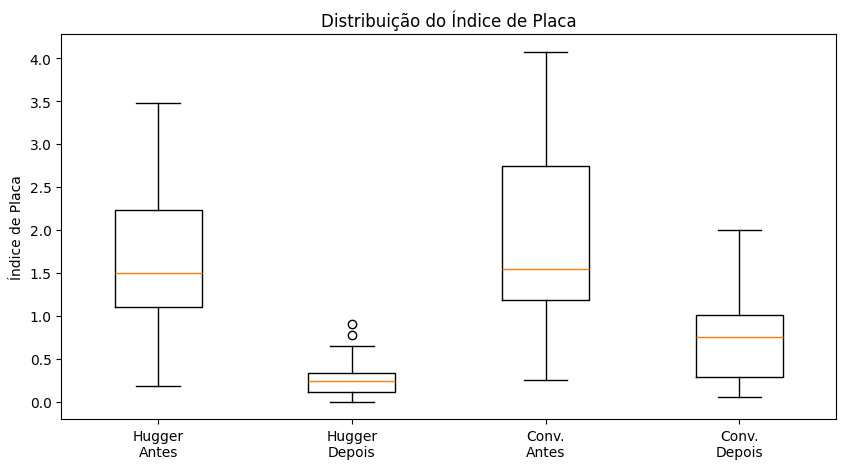

In [8]:
import matplotlib.pyplot as plt

colunas = ['Hugger_Antes_Escovacao', 'Hugger_Depois_Escovacao',
           'Convencional_Antes_Escovacao', 'Convencional_Depois_Escovacao']

plt.figure(figsize=(10, 5))
plt.boxplot([bacterias[c] for c in colunas], labels=['Hugger\nAntes', 'Hugger\nDepois', 'Conv.\nAntes', 'Conv.\nDepois'])
plt.title('Distribuição do Índice de Placa')
plt.ylabel('Índice de Placa')
plt.show()

#### 2. Histograma — ver o formato da distribuição de cada variável

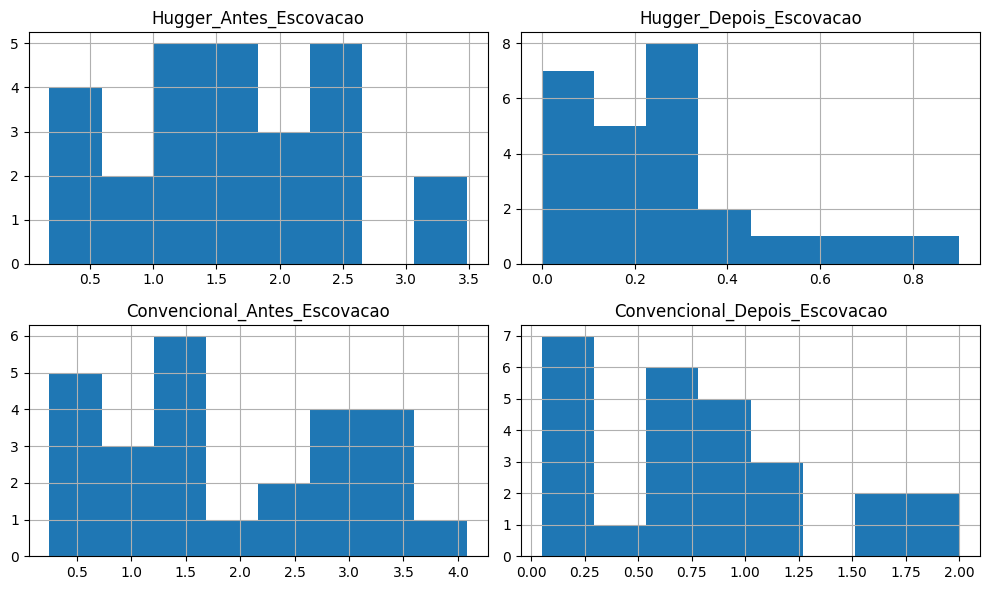

In [9]:
fig, axes = plt.subplots(2, 2, figsize=(10, 6))
for ax, col in zip(axes.flatten(), colunas):
    bacterias[col].hist(ax=ax, bins=8)
    ax.set_title(col)
plt.tight_layout()
plt.show()


#### 3. Gráfico de barras — comparar médias antes/depois por escova

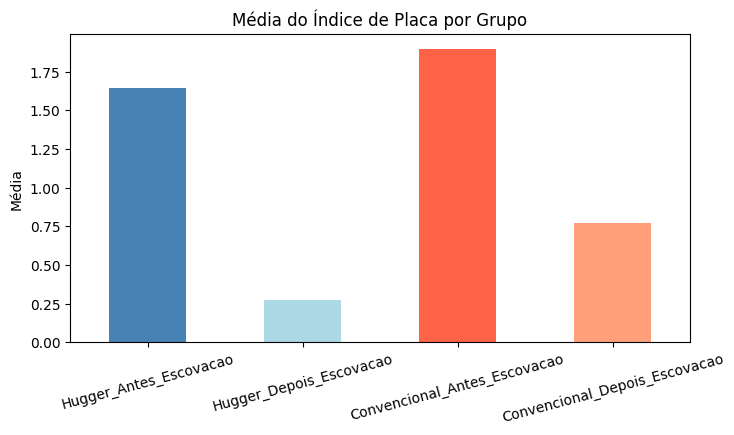

In [10]:
medias = bacterias[colunas].mean()
medias.plot(kind='bar', figsize=(8, 4), color=['steelblue', 'lightblue', 'tomato', 'lightsalmon'])
plt.title('Média do Índice de Placa por Grupo')
plt.ylabel('Média')
plt.xticks(rotation=15)
plt.show()


#### 4. Comparação por sexo — ver se o sexo influencia

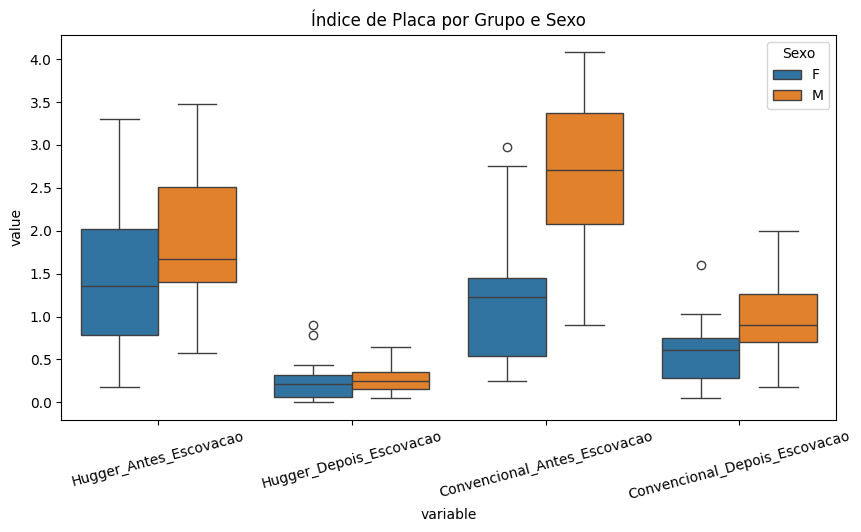

In [11]:
import seaborn as sns

plt.figure(figsize=(10, 5))
sns.boxplot(data=bacterias.melt(id_vars='Sexo', value_vars=colunas),
            x='variable', y='value', hue='Sexo')
plt.title('Índice de Placa por Grupo e Sexo')
plt.xticks(rotation=15)
plt.show()

#### 5. Aplicando Feature Engineering

In [12]:
bacterias['Convencional_Ind']=(bacterias['Convencional_Antes_Escovacao']-bacterias['Convencional_Depois_Escovacao'])/bacterias['Convencional_Antes_Escovacao']
bacterias

bacterias['Hugger_Ind']=(bacterias['Hugger_Antes_Escovacao']-bacterias['Hugger_Depois_Escovacao'])/bacterias['Hugger_Antes_Escovacao']
bacterias

,Sujeito,Sexo,Hugger_Antes_Escovacao,Hugger_Depois_Escovacao,Convencional_Antes_Escovacao,Convencional_Depois_Escovacao,Convencional_Ind,Hugger_Ind
0,1,F,2.18,0.43,1.20,0.75,0.375000,0.802752
1,2,F,2.05,0.08,1.43,0.55,0.615385,0.960976
2,3,F,1.05,0.18,0.68,0.08,0.882353,0.828571
3,4,F,1.95,0.78,1.45,0.75,0.482759,0.600000
4,5,F,0.28,0.03,0.50,0.05,0.900000,0.892857
5,6,F,2.63,0.23,2.75,1.60,0.418182,0.912548
6,7,F,1.50,0.20,1.25,0.65,0.480000,0.866667
7,8,F,0.45,0.00,0.40,0.13,0.675000,1.000000
8,9,F,0.70,0.05,1.18,0.83,0.296610,0.928571
9,10,F,1.30,0.30,1.43,0.58,0.594406,0.769231


/tmp/ipykernel_1644/3347980161.py:6: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  plt.boxplot([bacterias["Hugger_Ind"], bacterias["Convencional_Ind"]], labels=["Hugger", "Convencional"])


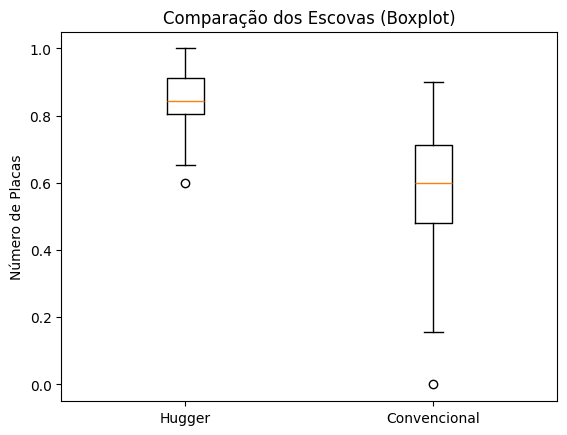

In [16]:
import matplotlib.pyplot as plt

plt.figure()

# Boxplot comparando os dois algoritmos
plt.boxplot([bacterias["Hugger_Ind"], bacterias["Convencional_Ind"]], labels=["Hugger", "Convencional"])

plt.title("Comparação dos Escovas (Boxplot)")
plt.ylabel("Número de Placas")

plt.show()

## **Conclusão**

**Análise 1 — Boxplot: Distribuição do Índice de Placa**

A escova Hugger apresentou mediana pós-escovação visivelmente inferior à Convencional, sugerindo maior eficácia na remoção de placa bacteriana.

**Análise 2 — Histograma: Formato da Distribuição**

Após a escovação, a distribuição do índice Hugger se concentra próxima ao zero, indicando remoção mais consistente e uniforme de placa em comparação ao modelo convencional.

**Análise 3 — Barras: Comparação de Médias**

A escova Hugger reduziu a média do índice de placa de 1,64 para 0,28, enquanto a Convencional foi de 1,90 para 0,77 — a Hugger entregou quase três vezes menos placa residual.

**Análise 4 — Boxplot por Sexo**

Apesar de pequenas variações entre meninas e meninos, o padrão de superioridade da escova Hugger se manteve em ambos os sexos, indicando que o sexo não é um fator determinante nos resultados.

**Análise 5 — Índice de Eficiência (Feature Engineering)**

Ao normalizar a remoção pelo índice inicial, a Hugger removeu em média ~83% da placa, contra ~57% da Convencional — uma diferença de 26 pontos percentuais que reforça a vantagem da nova escova.